In this code, we test the Auclair Ringeval expansion of vanilla slow roll in terms of HFFs (2205.12608).

Two runs are performed: one using phenomenological parameters (as Philippe did) and the other using HFFs.

The posterior curves from the two runs are then displayed together in the final plot.

The new mock data are also incorporated.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
import pandas as pd
from functools import partial
import math
import emcee
import corner
import scipy.integrate as integrate
%matplotlib inline

In [2]:
hc = 0.6736 #1807.06209 TT,TE,EE+lowE+lensing
f_set = 1/(315360000) #1/10y in julian
MPc = 3.0857*10**22 #In m
H_0 = 67.36 #In kms-1Mpc-1 1807.06209
H_0s = H_0*1000 / MPc
T_0 = 2.35*10**(-4) #In eV
T_eq = T_0*(1 + 3402) #eV #1807.06209
c = 299792458.0 #In m/s
Om_Mat = 0.3153 #1807.06209
Om_Rad = 2.47 * 10**(-5) / hc**2
M_PL = 1.2*10**(28) #in eV
k_b = 8.617*10**(-5) #in eV
h_bar = 6.582*10**(-16) #in eVs
As = 2.1*10**(-9) #1801.04268
f_CMB = (c/(2*np.pi))*0.05/(MPc) #1511
f_BBN = 3*10**(-13) # in Hz
f_pl = 1.854 * 10**(43) #In Hz
N_neut = 0.39 # from Planck lihelihoods
bbnbound = 5.6*10**(-6)*N_neut
f_0 = H_0*1000/(2*np.pi*MPc) #In Hz
eta_0 =2*(H_0s)**(-1)*1/(np.sqrt(Om_Rad + Om_Mat) + np.sqrt(Om_Rad)) #In sec
eta_0star = 2*(H_0*1000/MPc)**(-1)/np.sqrt(Om_Mat)
H_end = 4.068768589322154e+23 # in eV
f_LVK = 25 #min in 1310.5300
Om_LVK = 1.7 * 10**(-8) #2101.12130 flat GWB (prior)
T_BBN = 10**(5) #In eV 1801.04268
f_pl = 1.854 * 10**(43) #In Hz
f_eq = np.sqrt(2)*H_0s * Om_Mat/np.sqrt(Om_Rad) / (2*np.pi)
f_eqstar = f_eq*(1/(np.sqrt(2)*2))
eta_eqstar = 2/(2*np.pi*f_eqstar)
bbnbcmb_bound = 6.9*10**(-6)
yr = 365*24*60*60 #in s
T = 10.3*yr #in s
C=-0.73
mean_ns = 0.9641 #eq (40a) of 1807.06209
std_ns = 0.0044
mean_alpha_ns = -0.0045
std_alpha_ns = 0.0067
k_0002 = 0.002 # Mpc-1
k_002 = 0.02 # Mpc-1
f_0002 = k_0002 * c / (2*np.pi*MPc)
f_002  = k_002 * c / (2*np.pi*MPc)
r_0002 = 0.044
r_002 = 0.184

In [75]:
# sampling of old data is in RMS, the simplest change is to get RMS values from the new data

#Philippe mock data (old)
f = np.array([10**(-8.7),10**(-8.4),10**(-8.1),10**(-7.8)])
RMS  = np.array([10**(-6.5),10**(-6.7),10**(-7.3),10**(-7.5)])
sigRMS = np.array([10**(-6.2) - 10**(-6.3),10**(-6.6) - 10**(-6.8),10**(-7.1) - 10**(-7.261), 10**(-7.2) - 10**(-7.3)])

data3 = pd.DataFrame({
    'f': f,
    'RMS': RMS,
    'sigRMS': sigRMS
})

Omega = 8 * np.pi**4 * T * f**5 * (RMS)**2 / H_0s**2 #2306.16227
sigOmega = 16 * np.pi**4 * T * f**5  * (RMS) * (sigRMS) / H_0s**2

data3 = data3.assign(
    Omega = Omega,
    sigOmega = sigOmega
)

#Philippe mock data (new)
data = np.genfromtxt("New_Points.txt")

RMS2 = np.sqrt(data[0,:]* H_0s**2 / (8* np.pi**4 *T * data[2,:]**5))
sigRMS2 = (1/2) * (H_0s**2 / (8 * np.pi**4 * T * data[2,:]**5 * data[0,:]))**(1/2) * np.sqrt(data[1,:]) # covariance squared errorbar

data2 = pd.DataFrame({
    'f': data[2,:],
    'RMS': RMS2,
    'sigRMS': sigRMS2,
    'Omega': data[0,:],
    'sigOmega': np.sqrt(data[1,:]) # covariance squared errorbar
})

#relative error
print(np.sqrt(data[1,:])/data[0,:])

[0.08256527 0.07127277 0.11077804 0.04698302 0.05075456 0.10011821
 0.07933387 0.09545695 0.08217195]


In [73]:
print(data3)
print(data2)

              f           RMS        sigRMS         Omega      sigOmega
0  1.995262e-09  3.162278e-07  1.297701e-07  1.679719e-10  1.378609e-10
1  3.981072e-09  1.995262e-07  9.269932e-08  2.114641e-09  1.964912e-09
2  7.943282e-09  5.011872e-08  2.460513e-08  4.219263e-09  4.142783e-09
3  1.584893e-08  3.162278e-08  1.297701e-08  5.311737e-08  4.359546e-08
              f           RMS        sigRMS         Omega      sigOmega
0  3.067065e-09  2.424675e-08  1.000970e-09  8.475366e-12  6.997709e-13
1  6.134130e-09  2.646233e-08  9.430218e-10  3.230410e-10  2.302403e-11
2  9.201195e-09  2.895943e-08  1.604034e-09  2.937905e-09  3.254554e-10
3  1.226826e-08  2.697703e-08  6.337312e-10  1.074335e-08  5.047551e-10
4  1.533533e-08  2.669877e-08  6.775423e-10  3.211324e-08  1.629893e-09
5  1.840239e-08  2.939225e-08  1.471350e-09  9.684415e-08  9.695863e-09
6  2.146946e-08  2.872555e-08  1.139455e-09  1.999302e-07  1.586124e-08
7  2.453652e-08  2.888034e-08  1.378415e-09  3.940089e-07  3.761

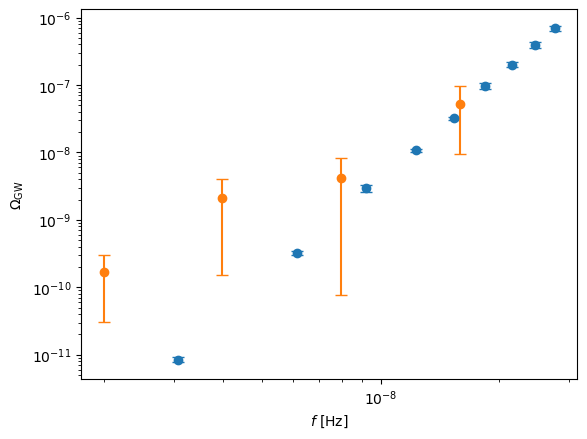

In [65]:
# new(blue) and old(orange) data points

plt.errorbar(data2['f'], data2['Omega'], yerr=data2['sigOmega'], fmt='o', capsize=4)
plt.errorbar(data3['f'], data3['Omega'] , yerr=data3['sigOmega'], fmt='o', capsize=4)
plt.xlabel(r'$f\ \mathrm{[Hz]}$')
plt.ylabel(r'$\Omega_{\mathrm{GW}}$');
plt.xscale('log')
plt.yscale('log')

In [8]:
params_pheno = ["Trhl","log_r","n_t","alpha","f_endl"] # phenomenological
params_sr = ["Trhl", "eps1", "eps2", "eps3", "f_endl"] # HFF

def unpack_pheno(theta):
    return dict(zip(params_pheno, theta))

def unpack_sr(theta):
    return dict(zip(params_sr, theta))

In [13]:
def S(f, Om):
    return Om * (H_0s)**2 / (8 * np.pi**4 * f**5)

S_LVK = S(f_LVK, Om_LVK)
modLVK = np.power(S_LVK/T,0.5)

In [15]:
def P(theta, f):
    r = 10**theta["log_r"]
    logPt = np.log(As * r * (f / f_CMB)**(theta["n_t"] + 0.5 * theta["alpha"] * np.log(f / f_CMB)))
    return np.exp(logPt)

def f_rh(theta):
    Trh = 10**theta["Trhl"]
    return 1/(2*np.pi)*Trh*T_0 / M_PL / h_bar*(np.pi**2 / 90)**(1/2)

def T1(f):
    return 1 + 1.57*(f/f_eq) + 3.42*(f/f_eq)**2 # Mat/rad part
    
def T2(theta,f):
    return (1 - 0.22*(f/f_rh(theta))**(1.5) + 0.65*(f/f_rh(theta))**2)**(-1) # Reh/rad part

def Ttavg(theta,f):
    return (Om_Mat)**2*(9/(2*(2*np.pi*f*eta_0)**4) * T1(f) * T2(theta,f)) * np.heaviside(10**theta["f_endl"] - f,1)

def model_2PP(theta,f):
    Pval = P(theta, f)
    Tval = Ttavg(theta,f)
    logOm = np.log(1/12*(2*np.pi*f/(H_0s))**2 * Pval * Tval)
    return np.exp(logOm)

def Omega_r(theta, f, r):
    theta2 = theta.copy()
    theta2["log_r"] = np.log10(r)
    return model_2PP(theta2, f)

def modelRMS(theta, f):
    return np.power(S(f,model_2PP(theta,f))/T,0.5)

def I_bbn(theta):
    u = np.linspace(np.log(f_BBN), np.log(10**theta["f_endl"]), 300)

    inte = (T * modelRMS(theta, np.exp(u))**2 * (8 * np.pi**4 * np.exp(u)**5) / H_0s**2)

    if not np.all(np.isfinite(inte)):
        return np.inf, np.inf

    int_bbn = np.trapz(inte, u)

    return int_bbn, 0.0

def ns(theta):
    return (1 + 
            (-2)*theta["eps1"] - theta["eps2"]
            -2*(theta["eps1"])**2 - (2*C+3)*theta["eps1"]*theta["eps2"] -C*theta["eps2"]*theta["eps3"])  #2nd order

def alpha_ns(theta):
    return (-2*theta["eps1"]*theta["eps2"] - theta["eps2"]*theta["eps3"])

def sr_to_pheno(d):
    Trhl = d["Trhl"]
    eps1 = d["eps1"]
    eps2 = d["eps2"]
    eps3 = d["eps3"]
    f_endl = d["f_endl"]

    n_t = -2*eps1 - 2*eps1**2 - 2*(C+1)*eps1*eps2

    r = 16*eps1 * (1
                   + C*eps2
                   - (1/8)*(np.pi**2 - 4*C**2 - 8)*eps2**2
                   - (np.pi**2/2 - C - 4)*eps1*eps2
                   - (1/24)*(np.pi**2 - 12*C**2)*eps2*eps3)

    alpha = -2 * eps1 * eps2

    return {
        "Trhl": Trhl,
        "log_r": np.log10(r),
        "n_t": n_t,
        "alpha": alpha,
        "f_endl": f_endl
    }

def log_prior_pheno(theta):
    if (6 < theta["Trhl"] < 12 
        and -40 < theta["log_r"] < -1.5
        and -6 < theta["n_t"] < 6 
        and -2 < theta["alpha"] < 2 
        and -11 < theta["f_endl"] < 9):
        return 0.0
    return -np.inf

#slow roll conditions as priors
def log_prior_sr(theta):
    if (6 < theta["Trhl"] < 12 
        and 0 < theta["eps1"] < 1 
        and -1 < theta["eps2"] < 1
        and -1 < theta["eps3"] < 1
        and -11 < theta["f_endl"] < 9):
        return 0.0
    return -np.inf

In [17]:
def log_post_pheno(theta, data):
    d = unpack_pheno(theta)

    if log_prior_pheno(d) == -np.inf:
        return -np.inf
    
    f = data["f"]
    dataRMS = data["RMS"]
    sig = data["sigRMS"]**2

    mod = modelRMS(d, f)
    chi2 = ((dataRMS - mod)**2) / sig

    #BBN
    if I_bbn(d)[0] > bbnbound:
        return -np.inf

    #LVK
    if np.any(modelRMS(d,f_LVK) > modLVK):
        return -np.inf

    #Reh/inf
    if 10**d["f_endl"] < f_rh(d):
        return -np.inf

    # r measurements from Planck
    if model_2PP(d, f_0002) > Omega_r(d, f_0002, r_0002):
        return -np.inf

    if model_2PP(d, f_002) > Omega_r(d, f_002, r_002):
        return -np.inf
        
    return -0.5 * np.sum(np.log(2 * np.pi * sig) + chi2) + log_prior_pheno(d)

def log_post_sr(theta, data):
    d_sr = unpack_sr(theta)

    if log_prior_sr(d_sr) == -np.inf:
        return -np.inf

    d_ph = sr_to_pheno(d_sr)

    f = data["f"]
    dataRMS = data["RMS"]
    sig = data["sigRMS"]**2

    mod = modelRMS(d_ph, f)
    chi2 = ((dataRMS - mod)**2) / sig

    #ns and alpha_s measurements from Planck
    chi2_ns = ((ns(d_sr) - mean_ns)/std_ns)**2
    chi2_alpha_ns = ((alpha_ns(d_sr) - mean_alpha_ns)/std_alpha_ns)**2

    if I_bbn(d_ph)[0] > bbnbound:
        return -np.inf

    if np.any(modelRMS(d_ph,f_LVK) > modLVK):
        return -np.inf

    if 10**d_ph["f_endl"] < f_rh(d_ph):
        return -np.inf

    if model_2PP(d_ph, f_0002) > Omega_r(d_ph, f_0002, r_0002):
        return -np.inf

    if model_2PP(d_ph, f_002) > Omega_r(d_ph, f_002, r_002):
        return -np.inf

    return (-0.5 * np.sum(np.log(2 * np.pi * sig) + chi2) 
            -0.5 * (np.log(2 * np.pi * std_ns**2) + chi2_ns) 
            -0.5 * (np.log(2 * np.pi * std_alpha_ns**2) + chi2_alpha_ns)
            + log_prior_sr(d_sr))

In [19]:
nwalkers = 20

# phenomenological sampling

ndim_ph = len(params_pheno)

p0_ph = np.c_[
    np.random.randn(nwalkers) * 0.1 + 7.5,   # Trhl
    np.random.randn(nwalkers) * 0.1 - 3.0,   # log_r
    np.random.randn(nwalkers) * 0.1 + 1.0,   # n_t
    np.random.randn(nwalkers) * 0.1 + 0.25,  # alpha
    np.random.randn(nwalkers) * 0.1 - 6.5    # f_endl
]

sampler_ph = emcee.EnsembleSampler(nwalkers,ndim_ph,log_post_pheno,args=[data2],a=1.5)
sampler_ph.run_mcmc(p0_ph, 10000, progress=True);

/var/folders/qb/mpw0pw513fdg_wslyqzyp5fr0000gn/T/ipykernel_8816/4024621039.py:22: RuntimeWarning: divide by zero encountered in log
  logOm = np.log(1/12*(2*np.pi*f/(H_0s))**2 * Pval * Tval)
  0%|                                                 | 0/10000 [00:00<?, ?it/s]/Users/ecedoga/opt/anaconda3/lib/python3.9/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
/Users/ecedoga/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
  0%|                                         | 4/10000 [00:00<05:07, 32.53it/s]/var/folders/qb/mpw0pw513fdg_wslyqzyp5fr0000gn/T/ipykernel_8816/4024621039.py:3: RuntimeWarning: divide by zero encountered in log
  logPt = np.log(As * r * (f / f_CMB)**(theta["n_t"] + 0.5 * theta["alpha"] * np.log(f / f_CMB)))
  4%|█▋                                     

In [20]:
# HFF sampling

ndim_sr = len(params_sr)

p0_sr = np.c_[
    np.random.randn(nwalkers) * 0.1 + 7.5,   # Trhl
    np.random.randn(nwalkers) * 0.1 + 0.25,   # eps1
    np.random.randn(nwalkers) * 0.1 + 0.25,   # eps2
    np.random.randn(nwalkers) * 0.1 + 0.25,   # eps3
    np.random.randn(nwalkers) * 0.1 - 6.5    # f_endl
]

sampler_sr = emcee.EnsembleSampler(nwalkers,ndim_sr,log_post_sr,args=[data2],a=1.5)
sampler_sr.run_mcmc(p0_sr, 10000, progress=True);

/var/folders/qb/mpw0pw513fdg_wslyqzyp5fr0000gn/T/ipykernel_8816/4024621039.py:22: RuntimeWarning: divide by zero encountered in log
  logOm = np.log(1/12*(2*np.pi*f/(H_0s))**2 * Pval * Tval)
  0%|                                         | 4/10000 [00:00<05:01, 33.19it/s]/var/folders/qb/mpw0pw513fdg_wslyqzyp5fr0000gn/T/ipykernel_8816/4024621039.py:72: RuntimeWarning: invalid value encountered in log10
  "log_r": np.log10(r),
 22%|████████▏                             | 2168/10000 [01:02<03:32, 36.82it/s]/var/folders/qb/mpw0pw513fdg_wslyqzyp5fr0000gn/T/ipykernel_8816/4024621039.py:3: RuntimeWarning: divide by zero encountered in log
  logPt = np.log(As * r * (f / f_CMB)**(theta["n_t"] + 0.5 * theta["alpha"] * np.log(f / f_CMB)))
100%|█████████████████████████████████████| 10000/10000 [04:03<00:00, 41.07it/s]


In [21]:
print(np.mean(sampler_ph.acceptance_fraction))
print(np.mean(sampler_sr.acceptance_fraction))

0.26608
0.046605


In [22]:
chain_ph = sampler_ph.get_chain()
burn_ph= int(0.25 * chain_ph.shape[0])
post_burn_ph = chain_ph[burn_ph:, :, :]
flat_chain_ph = post_burn_ph.reshape(-1, post_burn_ph.shape[2])

chain_sr = sampler_sr.get_chain()
burn_sr = int(0.25 * chain_sr.shape[0])
post_burn_sr = chain_sr[burn_sr:, :, :]
flat_chain_sr = post_burn_sr.reshape(-1, post_burn_sr.shape[2])

In [45]:
# adding the alpha_t calculated from HFFs in the chain for comparison purposes with pheno sampling

new_chain = np.column_stack((flat_chain_sr[:,0],
            flat_chain_sr[:,1],
            flat_chain_sr[:,2],
            flat_chain_sr[:,3],
            -2*flat_chain_sr[:,1]*flat_chain_sr[:,2],
            flat_chain_sr[:,4]))

print(new_chain)

[[ 7.48184475e+00  2.19948578e-01  3.64566925e-01  2.05785748e-01
  -1.60371953e-01 -6.44804104e+00]
 [ 7.69147641e+00  2.92986252e-01  2.87437554e-01  2.56544349e-01
  -1.68430503e-01 -6.55801982e+00]
 [ 7.44541452e+00  3.31518511e-01  7.97222018e-01 -8.07589484e-02
  -5.28587712e-01 -6.17390854e+00]
 ...
 [ 9.68443509e+00  1.15211145e-03  2.39253616e-02 -2.26827250e-01
  -5.51293659e-05  2.40270189e+00]
 [ 7.56048057e+00  3.48450225e-01  2.16628066e-01  1.98707661e-01
  -1.50968197e-01 -6.65261588e+00]
 [ 7.50505409e+00  2.96693896e-01  1.54600370e-01  3.55657255e-01
  -9.17379723e-02 -6.34658639e+00]]


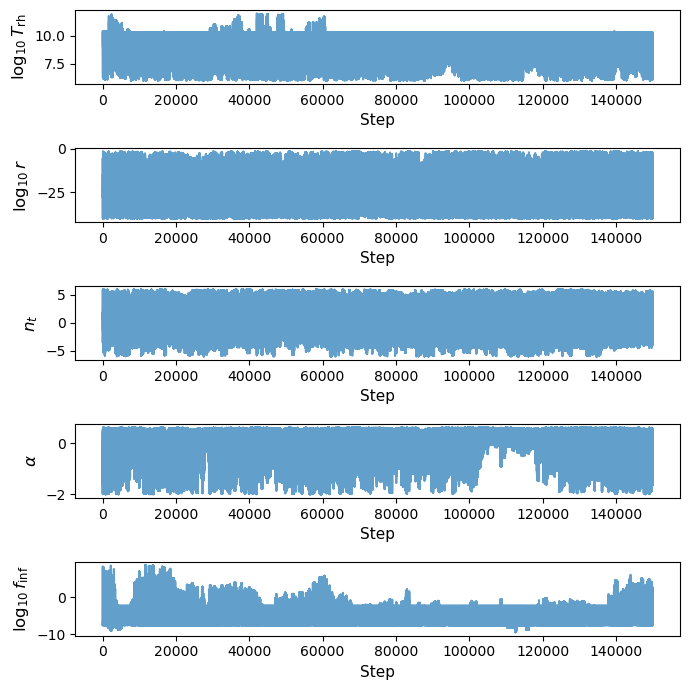

In [47]:
# chain convergence for pheno

param_names_ph = [r"$\log_{10} T_{\rm rh}$",r"$\log_{10} r$",r"$n_t$",r"$\alpha$",r"$\log_{10} f_{\rm inf}$"]
fig, axes = plt.subplots(ndim_ph, 1, figsize=(7, 7))
for i in range(ndim_ph):
    axes[i].plot(flat_chain_ph[:, i], alpha=0.7)
    axes[i].set_xlabel("Step", fontsize=11)
    axes[i].set_ylabel(param_names_ph[i], fontsize=12)
plt.tight_layout()
plt.show()

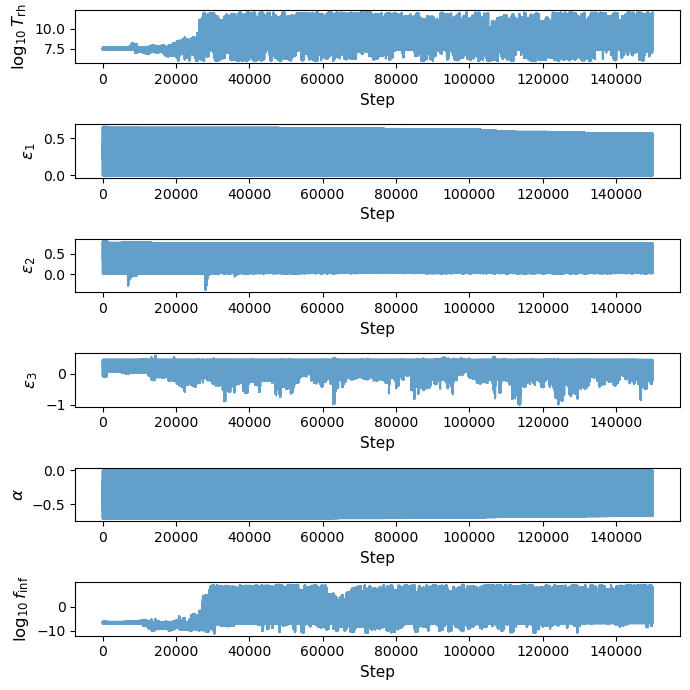

In [49]:
# chain convergence for sr

param_names_sr = [r"$\log_{10} T_{\rm rh}$",r"$ \epsilon_1$",r"$\epsilon_2$",r"$\epsilon_3$",r"$\alpha$",r"$\log_{10} f_{\rm inf}$"]
fig, axes = plt.subplots(ndim_sr+1, 1, figsize=(7, 7))
for i in range(ndim_sr+1):
    axes[i].plot(new_chain[:, i], alpha=0.7)
    axes[i].set_xlabel("Step", fontsize=11)
    axes[i].set_ylabel(param_names_sr[i], fontsize=12)
plt.tight_layout()
plt.show()

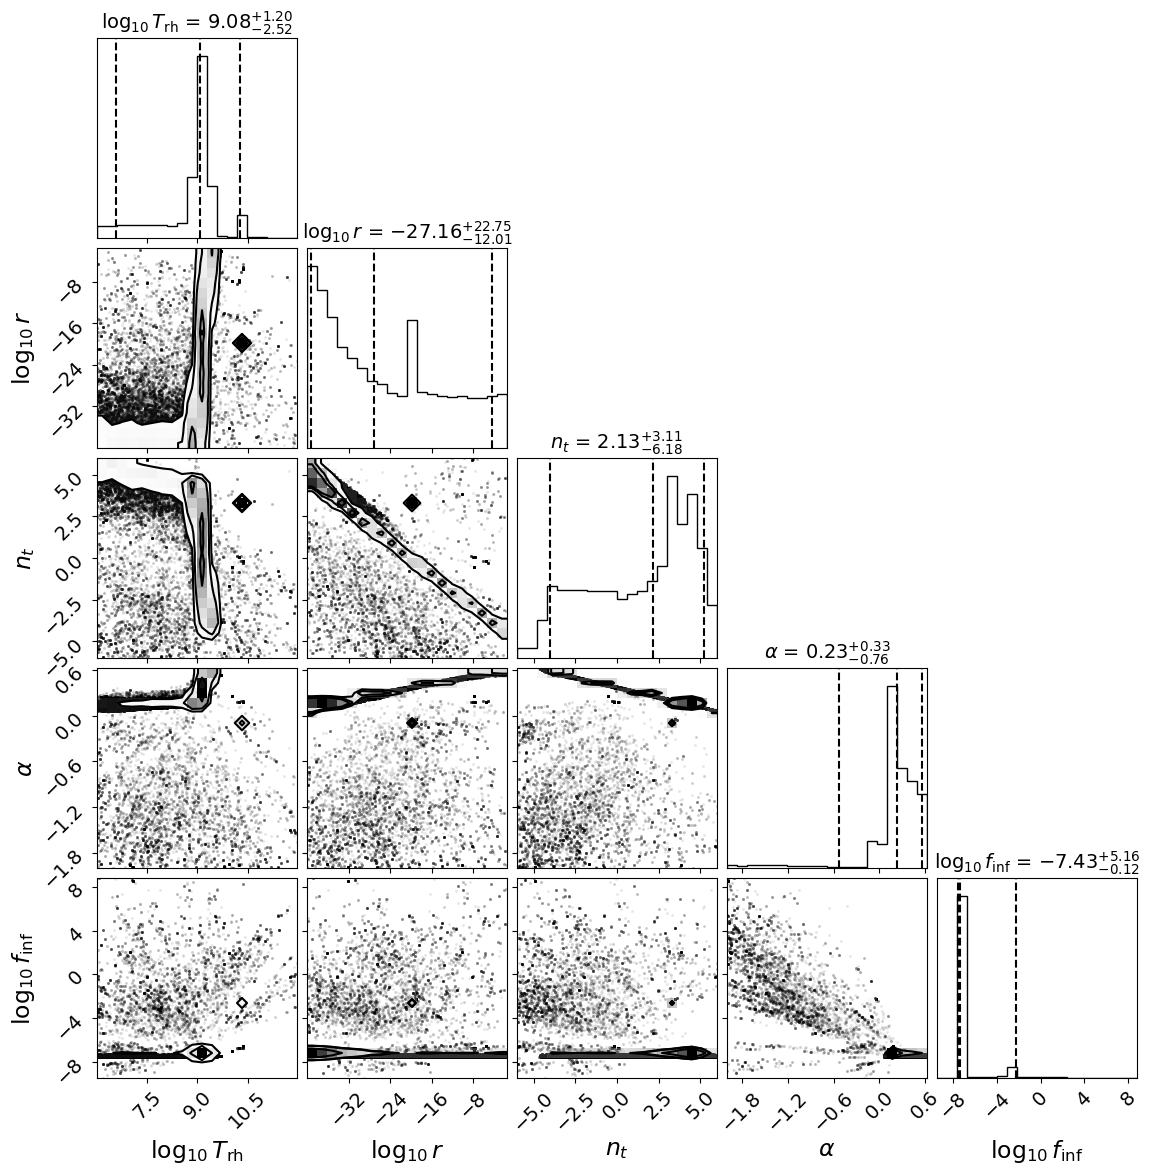

In [51]:
fig_ph = corner.corner(
    flat_chain_ph,
    labels=param_names_ph,
    show_titles=True,
    title_kwargs={"fontsize": 14},
    label_kwargs={"fontsize": 17},
    quantiles=[0.05, 0.5, 0.95],
    hist_kwargs={"density": True, "color": "black"},
)

for ax in fig_ph.get_axes():
    ax.tick_params(axis="both", labelsize=14)

'''fig_ph.savefig(
    "corner_pheno_2PP_running_BBNLVK_0_05Mpc.png",
    dpi=1000,
    bbox_inches="tight"
)''';

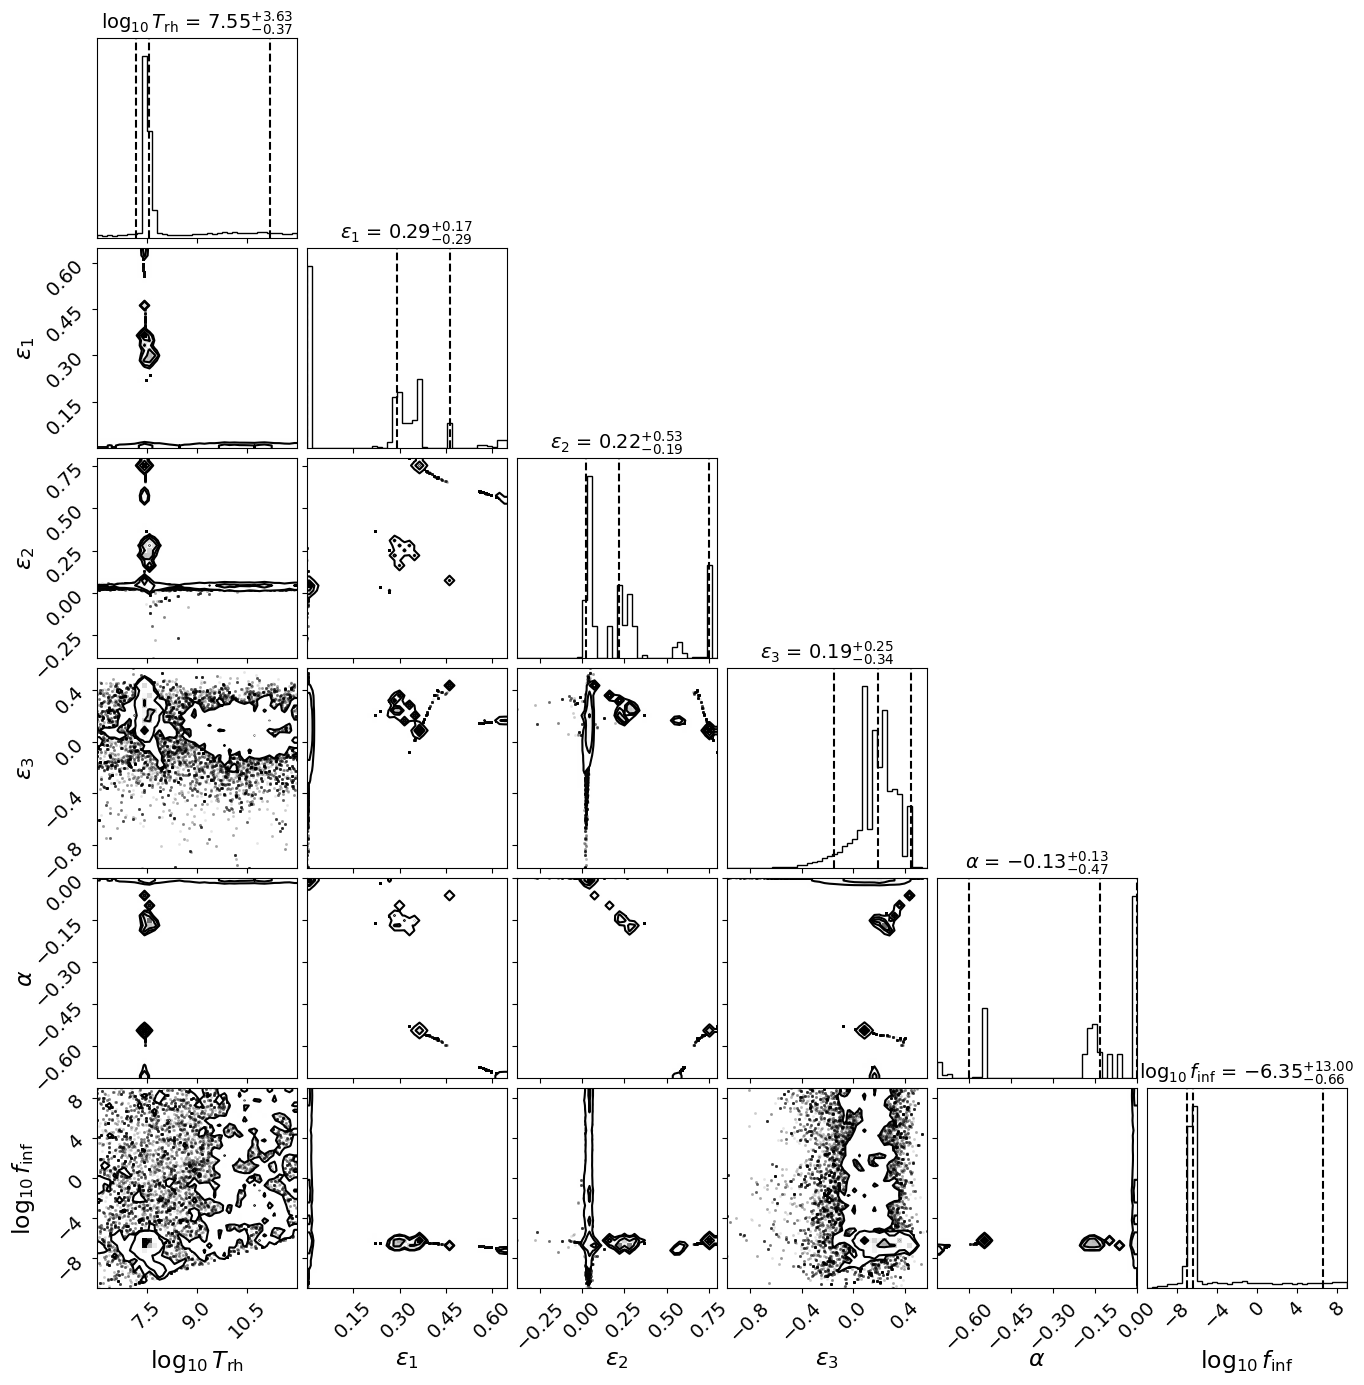

In [53]:
fig_sr = corner.corner(
    new_chain,
    labels=param_names_sr,
    bins=40,
    smooth=0.5,
    show_titles=True,
    title_kwargs={"fontsize": 14},
    label_kwargs={"fontsize": 17},
    quantiles=[0.05, 0.5, 0.95],
    hist_kwargs={"density": True, "color": "black"},
)

for ax in fig_sr.get_axes():
    ax.tick_params(axis="both", labelsize=14)

'''fig_sr.savefig(
    "corner_slowroll_2PP_running_BBNLVK_with_ns_and_running_0_05Mpc.png",
    dpi=1000,
    bbox_inches="tight"
)''';

In [87]:
# reduced chi2 of the blob for the run w/o the r constraints from Planck

blob_sr = {
    "Trhl": 6,
    "eps1": 0.3,
    "eps2": -0.4,
    "eps3": -0.7,
    "f_endl": -7
}

blob_pheno = sr_to_pheno(blob_sr)

print(blob_pheno)

mod = modelRMS(blob_pheno,data3["f"])

chi2 = np.sum(((mod-data3["RMS"])/data3["sigRMS"])**2)

print(chi2)

'''deg = len(blob_sr)
dat = len(data3["RMS"])
red_chi2 = chi2 / (dat - deg)

print(red_chi2)''';

{'Trhl': 6, 'log_r': 0.8445448060078165, 'n_t': -0.7152000000000001, 'alpha': 0.24, 'f_endl': -7}
12.582541457688713


In [59]:
N = 300

log_prob_ph = sampler_ph.get_log_prob()            
log_prob_ab_ph = log_prob_ph[burn_ph:, :]
log_prob_flat_ph = log_prob_ab_ph.reshape(-1)

max_value_ph = np.argmax(log_prob_flat_ph)
max_likelihood_ph = flat_chain_ph[max_value_ph]

value_N_ph = flat_chain_ph[np.random.choice(flat_chain_ph.shape[0], N, replace=False)]
value_200_ph = flat_chain_ph[np.random.choice(flat_chain_ph.shape[0], 200, replace=False)]

log_prob_sr = sampler_sr.get_log_prob()            
log_prob_ab_sr = log_prob_sr[burn_sr:, :]
log_prob_flat_sr = log_prob_ab_sr.reshape(-1)

max_value_sr = np.argmax(log_prob_flat_sr)
max_likelihood_sr = flat_chain_sr[max_value_sr]

value_N_sr = flat_chain_sr[np.random.choice(flat_chain_sr.shape[0], N, replace=False)]
value_200_sr = flat_chain_sr[np.random.choice(flat_chain_sr.shape[0], 200, replace=False)]

/var/folders/qb/mpw0pw513fdg_wslyqzyp5fr0000gn/T/ipykernel_8816/4024621039.py:22: RuntimeWarning: divide by zero encountered in log
  logOm = np.log(1/12*(2*np.pi*f/(H_0s))**2 * Pval * Tval)
/var/folders/qb/mpw0pw513fdg_wslyqzyp5fr0000gn/T/ipykernel_8816/4024621039.py:3: RuntimeWarning: divide by zero encountered in log
  logPt = np.log(As * r * (f / f_CMB)**(theta["n_t"] + 0.5 * theta["alpha"] * np.log(f / f_CMB)))


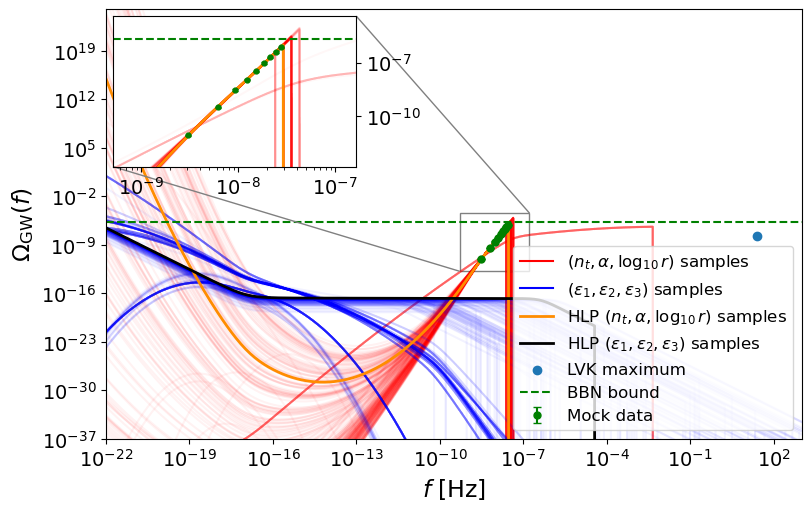

In [61]:
f_plt = np.logspace(-22, 3, 300)

fig, ax = plt.subplots(figsize=(8,5), constrained_layout=True)

for theta in value_N_ph:
    d = unpack_pheno(theta)
    ax.plot(f_plt, model_2PP(d, f_plt), alpha=0.05, color='red')

ax.plot([], [], color='red', label=r'$(n_t,\alpha,\log_{10} r)$ samples')

for theta in value_N_sr:
    d_sr = unpack_sr(theta) 
    d_ph = sr_to_pheno(d_sr)
    ax.plot(f_plt, model_2PP(d_ph, f_plt), alpha=0.05, color='blue')

ax.plot([], [], color='blue', label=r'$(\epsilon_1,\epsilon_2,\epsilon_3)$ samples')

d_ph_ml = unpack_pheno(max_likelihood_ph)
ax.plot(f_plt, model_2PP(d_ph_ml, f_plt), color="darkorange", lw=2, label=r'HLP $(n_t,\alpha,\log_{10} r)$ samples')

d_sr_ml = unpack_sr(max_likelihood_sr)
d_sr_ph_ml = sr_to_pheno(d_sr_ml)
ax.plot(f_plt, model_2PP(d_sr_ph_ml, f_plt), color="black", lw=2, label=r'HLP $(\epsilon_1,\epsilon_2,\epsilon_3)$ samples')

ax.errorbar(data2['f'], data2['Omega'], yerr=data2['sigOmega'], markersize=5, fmt='o', capsize=3, color='green', label="Mock data")

ax.scatter(f_LVK, Om_LVK, zorder=2, label=r"LVK maximum")

ax.axhline(bbnbound, linestyle='--', label='BBN bound', color='green')

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(1e-37, 1e25)
ax.set_xlim(1e-22, 1e3)
ax.set_xlabel(r'$f\ \mathrm{[Hz]}$', fontsize=17)
ax.set_ylabel(r"$\Omega_{\rm GW}(f)$", fontsize=17)
ax.tick_params(axis="both", which="both", labelsize=14)
ax.legend(fontsize=12,loc="lower right")

ax_zoom = inset_axes(ax, width="35%", height="35%", loc='upper left')
ax_zoom.set_xscale('log')
ax_zoom.set_yscale('log')
ax_zoom.yaxis.set_label_position('right')
ax_zoom.yaxis.tick_right()
ax_zoom.tick_params(axis="both", which="both", labelsize=14)

for theta in value_200_ph:
    d = unpack_pheno(theta)
    ax_zoom.plot(f_plt, model_2PP(d, f_plt), alpha=0.03, color='red')

for theta in value_200_sr:
    d_sr = unpack_sr(theta) 
    d_ph = sr_to_pheno(d_sr)
    ax_zoom.plot(f_plt, model_2PP(d_ph, f_plt), alpha=0.05, color='blue')

ax_zoom.plot(f_plt, model_2PP(d_ph_ml, f_plt), color="darkorange", lw=2)

ax_zoom.plot(f_plt, model_2PP(d_sr_ph_ml, f_plt), color="black", lw=2)

ax_zoom.errorbar(data2['f'], data2['Omega'], yerr=data2['sigOmega'], color='green', fmt='o', capsize=2, markersize=3.5)

ax_zoom.axhline(bbnbound, linestyle='--', label='BBN bound', color='green')

mark_inset(
    ax,
    ax_zoom,
    loc1=1,
    loc2=3,
    fc="none",
    ec="grey",
    lw=1
)

f_min, f_max = data2['f'].min(), data2['f'].max()
Omega_min, Omega_max = data2['Omega'].min(), data2['Omega'].max()
ax_zoom.set_xlim(f_min/6, f_max*6)
ax_zoom.set_ylim(Omega_min/55, Omega_max*55);

# plt.savefig("2PP_running_post_Doga_BBNLVK_ pheno_andsr_sampling_with_ns_8000steps_shrinked_errorbars.png", dpi=1000)